# Overview

This notebook builds and evaluates a **distance‑3 planar surface code** in Qiskit.

- Construct the d=3 layout (data qubits and stabilizer ancillas) and circuits for **single‑round** and **k‑round (space–time)** syndrome extraction.
- Define a simple depolarising **noise model** with readout error.
- Implement lightweight **MWPM decoders**: 2D for single‑round and 3D (space–time) for time‑differenced syndromes.
- Run **Monte‑Carlo sweeps** over physical error rate and compare logical‑X / logical‑Z failure rates.
- Generate a **comparison plot**: single‑round vs space–time decoding.

## Reproduce

- Python ≥ 3.9
- Install deps:
```bash
pip install qiskit networkx numpy matplotlib
```
- Then run this notebook top‑to‑bottom. For a quick demo, keep the defaults; for a longer run, increase `shots` in the **Simulation** section.


In [1]:
# Import dependencies

import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from qec.geometry import (
    d_idx,
    PLAQS,
    ANC_POS,
    TOP_Y,
    BOT_Y,
    LEFT_X,
    RIGHT_X,
    GRID_SPAN,
    manhattan,
)

from qec.syndrome import (
    split_into_rounds,
    parse_round_bits,
    defects_from_bits,
    spacetime_defects,
)

from qec.noise import depol_noise_model

from qec.decoder import (
    distance_to_vertical_boundary,
    distance_to_horizontal_boundary,
    mwpm_pairs,
    ancilla_pos_3d,
    mwpm_3d,
    decode_one_shot,
    decode_spacetime_one_shot,
    correction_spans_code
)

ModuleNotFoundError: No module named 'syndrome'

In [ ]:
# d=3 planar code: 3x3 data qubits, 4 X- and 4 Z-stabilizers (ancillas)

from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.noise.errors import depolarizing_error, ReadoutError
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

## Table of Contents

- [1. Data Structure](#data)
- [2. Syndrome Extraction](#syndrome)
- [3. Depolarising Noise Model](#noise)
- [4. MWPM Decoder Scaffold](#decoder)
- [5. Evaluation Metrics](#eval)
- [6. Simulations](#sim)

# 2. Syndrome Extraction
<a id="syndrome"></a>

Syndrome Extraction (one round)

In [ ]:
def one_round_surface_d3():
    """
    Returns a circuit with:
      - 9 data qubits
      - 4 X-ancillas (indices 9..12), 4 Z-ancillas (indices 13..16)
      - 8 classical bits storing [X syndromes | Z syndromes]
    """
    n_data = 9
    n_x = 4
    n_z = 4
    x_start = n_data                  # 9..12
    z_start = n_data + n_x            # 13..16

    qreg = QuantumRegister(n_data + n_x + n_z, "q")
    creg = ClassicalRegister(n_x + n_z, "syn")  # [X | Z]
    qc = QuantumCircuit(qreg, creg)

    # --- X stabilizers (measure XXXX) ---
    for s, plaq in enumerate(PLAQS):
        a = x_start + s  # ancilla index
        qc.h(a)          # prepare |+>
        for (r,c) in plaq:
            qc.cx(a, d_idx(r,c))      # CNOT ancilla -> data (parity of X)
        qc.h(a)                       # return to Z basis
        qc.measure(a, s)              # measure into syn[0..3]

    # --- Z stabilizers (measure ZZZZ) ---
    for s, plaq in enumerate(PLAQS):
        a = z_start + s
        for (r,c) in plaq:
            qc.cx(d_idx(r,c), a)      # parity of Z
        qc.measure(a, n_x + s)        # measure into syn[4..7]

    return qc

Syndrome Extraction (space-time encdoing of k rounds) 

In [ ]:
# Space-time encoding ensures each round’s ancilla starts clean; XOR of consecutive rounds isolates whether 
# changes came from data errors (flip persists in space) or measurement errors (flip only in time).

In [ ]:
# same constants
n_data, n_x, n_z = 9, 4, 4
x_start = n_data          # 9..12
z_start = n_data + n_x    # 13..16

def k_rounds_surface_d3(k: int) -> QuantumCircuit:
    """
    Build d=3 planar surface-code circuit with k rounds of syndrome extraction.
    """
    qreg = QuantumRegister(n_data + n_x + n_z, "q")
    qc = QuantumCircuit(qreg)

    for r in range(k):
        # simple memory error opportunity on data (lets 'id' pick up depolarizing)
        for q in range(9): 
            qc.id(q)
        syn = ClassicalRegister(n_x + n_z, f"syn_{r}")  # 8 bits for this round
        qc.add_register(syn)

        # --- X stabilizers: ancilla -> data (H, CNOTs, H, measure), reset ancilla
        for s, plaq in enumerate(PLAQS):
            a = x_start + s
            qc.reset(qreg[a])
            qc.h(qreg[a])
            for (row, col) in plaq:
                qc.cx(qreg[a], qreg[d_idx(row, col)])
            qc.h(qreg[a])
            qc.measure(qreg[a], syn[s])  # X syndrome bit s
            # (reset done above; no reset after measure needed)

        # --- Z stabilizers: data -> ancilla (CNOTs), measure, reset ancilla
        for s, plaq in enumerate(PLAQS):
            a = z_start + s
            qc.reset(qreg[a])
            for (row, col) in plaq:
                qc.cx(qreg[d_idx(row, col)], qreg[a])
            qc.measure(qreg[a], syn[n_x + s])  # Z syndrome bit s

    return qc

# 4. MWPM Decoder Scaffold
<a id="decoder"></a>

In [ ]:
# Minimum-Weight Perfect Matching tries to pair up all defects with the shortest possible correction paths.
# Each defect is represented as a node in a graph and edge weights = “cost” (distance) between two defects.
# If have an odd number of defects, add a boundary node (B).

# e.g. (a0, a3) — connect defect 0 to defect 3 with a correction chain.
#      (a2, B) — connect defect 2 to the nearest boundary.

In [ ]:
# Pseudocode
# INPUT: Zbits from last round (4 bits, one per Z plaquette)
# 1. Find defects = indices of '1' bits
# 2. Make graph G, nodes = defect labels ('a0', 'a1', ...)
# 3. If odd number of defects → add boundary node 'B'
# 4. Connect all pairs with edges weighted by distance
# 5. Run MWPM → get matched pairs
# 6. These pairs = correction paths to apply

# 5. Evaluation Metrics
<a id="eval"></a>

In [ ]:
def logical_failure_rates_single(k=1, shots=4000, p1=0.01, ro=0.0):
    sim = AerSimulator()
    qc = k_rounds_surface_d3(k)
    tc = transpile(qc, sim, basis_gates=['id','rz','sx','x','h','cx','measure'],
                   optimization_level=1)
    nm = depol_noise_model(p1=p1, ro=ro)  # includes readout error

    res = sim.run(tc, shots=shots, noise_model=nm).result()
    counts = res.get_counts()

    failX = failZ = total = 0
    for bitstr, n in counts.items():
        lx, lz = decode_one_shot(bitstr, k=k)   # last-round-only decoder
        failX += lx * n
        failZ += lz * n
        total += n
    return failX/max(1,total), failZ/max(1,total)

In [ ]:
# use space-time encoding when k>=3

def logical_failure_rates_spacetime(k=3, shots=4000, p1=0.01, ro=0.01):
    sim = AerSimulator()
    qc = k_rounds_surface_d3(k)
    tc = transpile(qc, sim, basis_gates=['id','rz','sx','x','h','cx','measure'], optimization_level=1)
    nm = depol_noise_model(p1=p1, ro=ro)

    res = sim.run(tc, shots=shots, noise_model=nm).result()
    counts = res.get_counts()

    failX = failZ = total = 0
    for bitstr, n in counts.items():
        lx, lz = decode_spacetime_one_shot(bitstr, k)
        failX += lx * n
        failZ += lz * n
        total += n

    return failX/max(1,total), failZ/max(1,total)

# 6. Simulations
<a id="sim"></a>

1 Round Syndrome Extraction Simulation

In [ ]:
sim = AerSimulator()
basis = ['id','rz','sx','x','h','cx','measure']

qc = one_round_surface_d3()
tc = transpile(qc, sim, basis_gates=basis, optimization_level=1)

noise = depol_noise_model(p1=0.01, ro=0.01)   # tweak p1 to see more/less defects
res = sim.run(tc, shots=2000, noise_model=noise).result()
counts = res.get_counts()

print("num distinct syndromes:", len(counts))
list(counts.items())[:5]

# quick parse: convert bitstring 'xxxxzzzz' -> (X_syndrome, Z_syndrome)
def parse_syndrome(bitstr, n_x=4):
    s = bitstr.replace(' ', '')  # just in case
    s = s[::-1]
    return s[:n_x], s[n_x:]

# show top-5 most common syndromes
top = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:5]
for bits, n in top:
    xs, zs = parse_syndrome(bits, 4)
    print(f"{bits:>10}  shots={n:4d}   X={xs}  Z={zs}")

c:\wzf\学习\qec-surface-code-sim\.venv\Lib\site-packages\qiskit\compiler\transpiler.py:276: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


num distinct syndromes: 256
  11100001  shots=  18   X=1000  Z=0111
  10101001  shots=  16   X=1001  Z=0101
  10100101  shots=  16   X=1010  Z=0101
  00101100  shots=  15   X=0011  Z=0100
  11010000  shots=  14   X=0000  Z=1011


K Rounds Simulation (comparing single round vs space-time syndrome extraction)

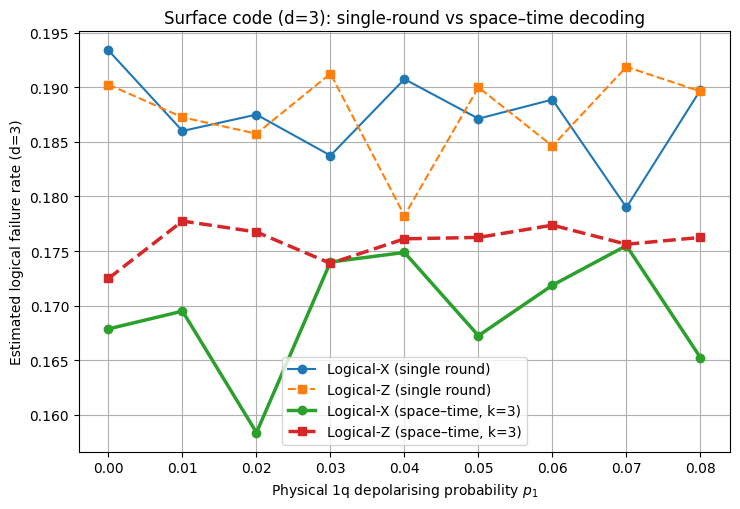

In [ ]:
# --- sweep + plot: single-round vs space–time (k>=3 recommended for space-time) ---
def compare_single_vs_spacetime(p_vals, k_space_time=3, k_single=1, shots=6000, ro=0.01):
    pLX_1, pLZ_1, pLX_ST, pLZ_ST = [], [], [], []
    for p in p_vals:
        # single-round baseline
        fx1, fz1 = logical_failure_rates_single(k=k_single, shots=shots, p1=p, ro=ro)
        pLX_1.append(fx1); pLZ_1.append(fz1)
        # space–time (time differencing)
        fxst, fzst = logical_failure_rates_spacetime(k=k_space_time, shots=shots, p1=p, ro=ro)
        pLX_ST.append(fxst); pLZ_ST.append(fzst)
    return (np.array(p_vals),
            np.array(pLX_1), np.array(pLZ_1),
            np.array(pLX_ST), np.array(pLZ_ST))

# run the comparison
p_vals = np.linspace(0.0, 0.08, 9)
ps, pLX_1, pLZ_1, pLX_ST, pLZ_ST = compare_single_vs_spacetime(
    p_vals, k_space_time=3, k_single=1, shots=8000, ro=0.01
)

# plot (optionally save)
save_path = None  # e.g., "image-results/1.png"
plt.figure(figsize=(7.5,5.2))
plt.plot(ps, pLX_1, 'o-',  label='Logical-X (single round)')
plt.plot(ps, pLZ_1, 's--', label='Logical-Z (single round)')
plt.plot(ps, pLX_ST, 'o-',  linewidth=2.5, label='Logical-X (space–time, k=3)')
plt.plot(ps, pLZ_ST, 's--', linewidth=2.5, label='Logical-Z (space–time, k=3)')
plt.xlabel('Physical 1q depolarising probability $p_1$')
plt.ylabel('Estimated logical failure rate (d=3)')
plt.title('Surface code (d=3): single-round vs space–time decoding')
plt.grid(True); plt.legend(); plt.tight_layout()

if save_path:
    import os
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300)
    print(f"Plot saved to {save_path}")

plt.show()